# D-SymBIA Scenario Exploration and Comparison

IAT 882: Final Project - By Minahil Faisal

**The problem statement:**

D-SymBIA is a decision-support tool for architects and urban designers that currently allows generation of one Building-Integrated Agriculture (BIA) scenario at a time. A scenario consists of a combination of crops, growing systems, locations on a building, and circular resource-recovery technologies (like rainwater harvesting or anaerobic digestion). 

However, it doesn't support comparison of several scenarios side by side to understand the trade-offs between them (e.g., "this scenario yields more food but costs more energy" vs. "this one recovers more water but yields less").

This notebook intends to investigate and solve two problem components building toward that comparison capability:

- **Problem A (Unsupervised - Clustering):** Given a set of scenarios, each with engineered performance KPIs (yield, resource intensity, circularity), discover natural performance categories, which are basically clusters of scenarios that share similar trade-off profiles. This aims to allow users to quickly see "high-yield/resource-heavy" vs. "modest-yield/circular" groupings rather than reading a flat table of multiple scenarios.
- **Problem B (Supervised - Classification):** Given only a scenario's design choices (which crops, which location types, which resource loop categories), i.e., information available before a full scenario is generated and its KPIs computed, we want to predict which performance category it potentially belongs to, so that a user can see the categorization within the generation step itself, while making choices, instead of making decisions, then viewing the evaluation at the end of the generation and exploration step.

The circular workflow we want to implement for the stakeholders working with D-SymBIA is as follows, where users can return to any step at any time without having to restart the entire workflow from the beginning.

```mermaid
graph TD;
    Generation-->Exploration;
    Generation-->Evaluation;
    Exploration-->Evaluation;
    Exploration-->Generation;
    Evaluation-->Exploration;
    Evaluation-->Generation;
```

This notebook currently focuses on Phase 1, which is cleaning, merging and organizing the data to build the KPI dataset and exploring it. Clustering (Problem A) and classification (Problem B) will be addressed in Phase 2.

## Datasets and Libraries

In [485]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
plt.rcParams["patch.edgecolor"] = "white"

# Plot Colors
colors = {
    "locations": "#4c72b0",
    "crops": "#3b7a57",
    "resources": "#dd8452",
    "scenarios": "#D2B48C",
    "kpis": "#0642a4",
}

In [486]:
# Load the data
crops = pd.read_csv('crops_systems.csv')
locations = pd.read_csv('locations.csv')
resources = pd.read_csv('resource_loops.csv')
scenario_cl = pd.read_csv('scenario_crop_locations.csv')
scenario_r = pd.read_csv('scenario_resource_loops.csv')

In [487]:
# Check shapes
print(f"crops_systems: {crops.shape}")
print(f"locations:{locations.shape}")
print(f"resource_loops: {resources.shape}")
print(f"scenario_crop_locations: {scenario_cl.shape}")
print(f"scenario_resource_loops: {scenario_r.shape}")

crops_systems: (32, 17)
locations:(49, 28)
resource_loops: (17, 13)
scenario_crop_locations: (1143, 3)
scenario_resource_loops: (770, 2)


## Phase 1 - Explorattory Data Analysis (EDA)

### Data sources

All data originates from D-SymBIA's own verified databases, recombined into synthetic scenarios via a seeded RNG (`generate_scenarios.py`, seed=42). Every individual crop, location, and resource-loop record is real. Only the scenario combinations (`scenario_crop_locations.csv` and `scenario_resource_loops.csv`) are synthetic because real client scenario data was too less (10-15 records) to explore and find patterns.

| File | Rows | Data  | Description |
|---|---|---|---|
| `crops_systems.csv` | 32 | Crop-systems | Crop identity + growing system, with yield/water/energy/GHG/CO2/market-value rates |
| `locations.csv` | 49 | Building zones (in the same sample building) | Direction, orientation, area, seasonal DLI/temp/humidity ranges |
| `resource_loops.csv` | 17 | Circular-resource recovery loops | Circular resource-recovery tech (Water/Energy/Amendment category), recovery yield, cost, carbon |
| `scenario_crop_locations.csv` | 1,144 | Scenario, location, crop combinations | Which crop-system is placed at which specific location, within each scenario |
| `scenario_resource_loops.csv` | 771 | Scenario, resource loop combinations | Which resource loops serve each scenario (scenario-level, not tied to a location) |

### Known data quality issues

- `resource_loops.csv` row 16 (Biochar pyrolysis, Amendment category) has missing `annual_cost_cad`, `carbon_factor`, `carbon_unit`, `embodied_carbon`. However, none of these columns are used to generate KPIs, so this does not block KPI computation, but mentioning this here in case we want to calculate other KPIs with these values later, then these need to be searched for / estimated and filled in first.

### Crops Systems Data Exploration

In [488]:
crops.columns

Index(['crop_system_id', 'crop_name', 'cultivar', 'orientation', 'bia_system', 'temp_min', 'temp_max', 'dli_min', 'dli_max', 'hum_min',
       'hum_max', 'yield_kg_m2', 'water_l_kg', 'energy_kwh_kg', 'ghg_kg_kg', 'co2_uptake_kg_kg', 'market_value_cad_kg'],
      dtype='str')

We know that `crops_systems.csv` file contains the following columns:

| column | meaning |
|---|---|
| crop_system_id | unique ID |
| crop_name, cultivar, orientation, bia_system | crop identity + system it's grown in |
| temp_min/max, dli_min/max, hum_min/max | growing requirement ranges |
| yield_kg_m2 | yield per square metre |
| water_l_kg, energy_kwh_kg, ghg_kg_kg | resource intensity per kg produced |
| co2_uptake_kg_kg, market_value_cad_kg | CO2 uptake and market value per kg |

In [489]:
crops.info()
crops.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   crop_system_id       32 non-null     int64  
 1   crop_name            32 non-null     str    
 2   cultivar             32 non-null     str    
 3   orientation          32 non-null     str    
 4   bia_system           32 non-null     str    
 5   temp_min             32 non-null     int64  
 6   temp_max             32 non-null     int64  
 7   dli_min              32 non-null     float64
 8   dli_max              32 non-null     int64  
 9   hum_min              32 non-null     int64  
 10  hum_max              32 non-null     int64  
 11  yield_kg_m2          32 non-null     float64
 12  water_l_kg           32 non-null     float64
 13  energy_kwh_kg        32 non-null     float64
 14  ghg_kg_kg            32 non-null     float64
 15  co2_uptake_kg_kg     32 non-null     float64
 16  mar

,crop_system_id,temp_min,temp_max,dli_min,dli_max,hum_min,hum_max,yield_kg_m2,water_l_kg,energy_kwh_kg,ghg_kg_kg,co2_uptake_kg_kg,market_value_cad_kg
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000
mean,16.500000,19.281250,24.843750,14.625000,21.437500,57.812500,75.781250,65.781250,54.753125,5.634375,0.868125,0.142270,15.181250
std,9.380832,3.113284,3.303072,6.398084,8.159449,9.994958,8.241259,117.563019,38.915483,6.414480,0.573160,0.067588,12.267935
min,1.000000,10.000000,18.000000,0.500000,2.000000,40.000000,60.000000,1.500000,3.000000,0.500000,0.300000,0.082575,2.500000
25%,8.750000,18.000000,23.500000,12.000000,16.000000,50.000000,70.000000,5.875000,23.750000,0.500000,0.500000,0.099090,5.625000
50%,16.500000,19.000000,24.000000,14.000000,20.000000,60.000000,75.000000,17.500000,42.500000,3.000000,0.750000,0.132120,12.000000
75%,24.250000,20.000000,26.000000,22.000000,30.000000,60.000000,80.000000,56.250000,80.000000,7.000000,1.000000,0.165150,20.000000
max,32.000000,30.000000,35.000000,22.000000,30.000000,85.000000,95.000000,490.000000,150.000000,22.000000,3.200000,0.367000,45.900000


All columns seem to exist, be in the correct data formats, and ranges for the values seem to be reasonable, without any obvious outliers.

### Locations Systems Data Exploration

In [490]:
locations.columns

Index(['id', 'direction', 'orientation', 'area', 'dli_spr', 'dli_sum', 'dli_aut', 'dli_win', 'rad_spr', 'rad_sum', 'rad_aut', 'rad_win',
       'temp_spr_min', 'temp_spr_max', 'temp_sum_min', 'temp_sum_max', 'temp_aut_min', 'temp_aut_max', 'temp_win_min', 'temp_win_max',
       'hum_spr_min', 'hum_spr_max', 'hum_sum_min', 'hum_sum_max', 'hum_aut_min', 'hum_aut_max', 'hum_win_min', 'hum_win_max'],
      dtype='str')

We know that the `locations.csv` file contains the following columns:

| column | meaning |
|---|---|
| id, direction, orientation, area | building zone identity, facing, size (m²) |
| dli_/rad_/temp_/hum_ [spr/sum/aut/win] | seasonal daylight, radiation, temperature, humidity ranges |

We can see from the above table columns that we have daylight, radiation, temperature and humidity available for all four seasons. But for this project, we will only focus on the summer season for our KPI calculations.

**Assumptions Log**: 
- The compatibility KPI is calculated using summer seasonal values only, according to the proposal's KPI guideline. Location data also includes spring/autumn/winter DLI, temperature, humidity, and radiation ranges that are not currently incorporated into the KPI calculation. A possible issue with this is that a scenario with high compatability in the summers might not fair well in the rest of the seasons.

**Possible future work:**
- As seasonal data exists in the datasets, we can use all 4 for calculation / visualization of KPIs by grouping by season, and giving them a `season_compatibility_score` or similar to achieve more accurate scores and trade-off data for analysis.
- As the humidity columns exist for all 4 seasons, we can also take humidity into consideration when calculating the `compatibility_pct` KPI, and provide visualizations of trade-offs per scenario per season.

In [491]:
locations.info()
locations.describe()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            49 non-null     int64  
 1   direction     49 non-null     str    
 2   orientation   49 non-null     str    
 3   area          49 non-null     int64  
 4   dli_spr       49 non-null     float64
 5   dli_sum       49 non-null     float64
 6   dli_aut       49 non-null     float64
 7   dli_win       49 non-null     float64
 8   rad_spr       49 non-null     float64
 9   rad_sum       49 non-null     float64
 10  rad_aut       49 non-null     float64
 11  rad_win       49 non-null     float64
 12  temp_spr_min  49 non-null     int64  
 13  temp_spr_max  49 non-null     int64  
 14  temp_sum_min  49 non-null     int64  
 15  temp_sum_max  49 non-null     int64  
 16  temp_aut_min  49 non-null     int64  
 17  temp_aut_max  49 non-null     int64  
 18  temp_win_min  49 non-null     int64  
 19  

,id,area,dli_spr,dli_sum,dli_aut,dli_win,rad_spr,rad_sum,rad_aut,rad_win,temp_spr_min,temp_spr_max,temp_sum_min,temp_sum_max,temp_aut_min,temp_aut_max,temp_win_min,temp_win_max,hum_spr_min,hum_spr_max,hum_sum_min,hum_sum_max,hum_aut_min,hum_aut_max,hum_win_min,hum_win_max
count,49.00000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000,49.0,49.0,49.0,49.0,49.0,49.0,49.0,49.0,49.0,49.0,49.0,49.0,49.0,49.0,49.0,49.0
mean,25.00000,127.122449,13.592041,17.345918,9.161020,5.111429,169.275306,216.018980,112.851633,62.271633,1.0,20.0,8.0,28.0,-2.0,24.0,-9.0,13.0,39.0,100.0,36.0,100.0,26.0,100.0,38.0,100.0
std,14.28869,169.761307,7.331743,9.501014,5.912159,4.034251,91.310645,118.336575,72.825528,49.155608,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,1.00000,4.000000,0.380000,0.530000,0.160000,0.100000,4.730000,6.620000,2.010000,1.190000,1.0,20.0,8.0,28.0,-2.0,24.0,-9.0,13.0,39.0,100.0,36.0,100.0,26.0,100.0,38.0,100.0
25%,13.00000,31.000000,8.300000,11.250000,4.410000,2.120000,103.390000,140.090000,54.380000,25.770000,1.0,20.0,8.0,28.0,-2.0,24.0,-9.0,13.0,39.0,100.0,36.0,100.0,26.0,100.0,38.0,100.0
50%,25.00000,56.000000,13.990000,17.470000,8.610000,4.030000,174.240000,217.570000,106.070000,49.150000,1.0,20.0,8.0,28.0,-2.0,24.0,-9.0,13.0,39.0,100.0,36.0,100.0,26.0,100.0,38.0,100.0
75%,37.00000,156.000000,18.600000,22.250000,13.760000,6.740000,231.590000,277.100000,169.450000,82.100000,1.0,20.0,8.0,28.0,-2.0,24.0,-9.0,13.0,39.0,100.0,36.0,100.0,26.0,100.0,38.0,100.0
max,49.00000,742.000000,30.570000,42.850000,22.540000,15.990000,380.760000,533.670000,277.670000,194.830000,1.0,20.0,8.0,28.0,-2.0,24.0,-9.0,13.0,39.0,100.0,36.0,100.0,26.0,100.0,38.0,100.0


All columns seem to exist, be in the correct data formats, and ranges for the values seem to be reasonable, without any obvious outliers.

### Resource Loops Data Exploration

In [492]:
resources.columns

Index(['resource_loop_id', 'source', 'tech', 'output_type', 'recovery_yield_frac', 'space_m2', 'energy_kwh', 'energy_unit', 'category',
       'annual_cost_cad', 'carbon_factor', 'carbon_unit', 'embodied_carbon'],
      dtype='str')

We know that `resource_loops.csv` file contains the following columns:

| column | meaning |
|---|---|
| resource_loop_id, tech, output_type, category | circular technology identity (Water/Energy/Amendment) |
| recovery_yield_frac | fraction of input recovered as output |
| space_m2, energy_kwh, annual_cost_cad, carbon_factor, embodied_carbon | resource/cost/carbon footprint of the technology |

In [493]:
resources.info()
resources.describe()

<class 'pandas.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   resource_loop_id     17 non-null     int64  
 1   source               17 non-null     str    
 2   tech                 17 non-null     str    
 3   output_type          17 non-null     str    
 4   recovery_yield_frac  17 non-null     float64
 5   space_m2             17 non-null     int64  
 6   energy_kwh           17 non-null     float64
 7   energy_unit          17 non-null     str    
 8   category             17 non-null     str    
 9   annual_cost_cad      16 non-null     float64
 10  carbon_factor        16 non-null     float64
 11  carbon_unit          16 non-null     str    
 12  embodied_carbon      16 non-null     float64
dtypes: float64(5), int64(2), str(6)
memory usage: 3.0 KB


,resource_loop_id,recovery_yield_frac,space_m2,energy_kwh,annual_cost_cad,carbon_factor,embodied_carbon
count,17.000000,17.000000,17.000000,17.000000,16.000000,16.000000,16.000000
mean,9.000000,0.970588,12.941176,3.276471,3012.500000,0.518750,250.093750
std,5.049752,1.022720,9.781811,9.752769,1934.209572,0.669297,146.418193
min,1.000000,0.100000,1.000000,0.020000,1000.000000,0.200000,50.000000
25%,5.000000,0.400000,4.000000,0.100000,1450.000000,0.250000,181.225000
50%,9.000000,0.800000,15.000000,0.300000,2300.000000,0.400000,233.300000
75%,13.000000,0.900000,15.000000,0.500000,5000.000000,0.400000,400.000000
max,17.000000,3.600000,30.000000,40.000000,6000.000000,3.000000,480.000000


All columns seem to exist, be in the correct data formats, and ranges for the values seem to be reasonable, without any obvious outliers.

### Scenarios With Crops and Locations Data Exploration

In [494]:
scenario_cl.columns

Index(['scenario_id', 'location_id', 'crop_system_id'], dtype='str')

We know that the generated `scenario_crop_locations.csv` file contains the following columns:

| column | meaning |
|---|---|
| scenario_id | unique scenario ID |
| location_id | a specific location zone (references `locations.csv` `id`) |
| crop_system_id | a specific crop-system placed at that location (references `crops_systems.csv`) |

Each row represents a scenario (location, and crop) combination, for example, a scenario with 3 locations, each hosting 2 crops has 6 rows in the data file. Each crop is tied to the specific location it is grown in.


In [495]:
scenario_cl.info()
scenario_cl.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   scenario_id     1143 non-null   int64
 1   location_id     1143 non-null   int64
 2   crop_system_id  1143 non-null   int64
dtypes: int64(3)
memory usage: 26.9 KB


,scenario_id,location_id,crop_system_id
count,1143.000000,1143.000000,1143.000000
mean,148.292213,25.832896,17.062992
std,86.824815,14.211533,9.288218
min,1.000000,1.000000,1.000000
25%,73.000000,14.000000,9.000000
50%,147.000000,26.000000,17.000000
75%,222.000000,39.000000,25.000000
max,300.000000,49.000000,32.000000


All columns seem to exist, be in the correct data formats, and ranges for the values seem to be reasonable, without any obvious outliers.

### Scenarios With Resource Loops Data Exploration

In [496]:
scenario_r.columns

Index(['scenario_id', 'resource_loop_id'], dtype='str')

We know that the generated `scenario_resource_loops.csv` file contains the following columns:

| column | meaning |
|---|---|
| scenario_id | unique scenario ID |
| resource_loop_id | a resource loop used in that scenario (references `resource_loops.csv`) |

Resource loops are kept at the scenario level rather than paired to a specific location. Technologies like anaerobic digesters or solar PV belong to a whole building, providing its resource, not only for one location where a BIA system exists.

The `scenario_id`s here overlap with those in `scenario_crop_locations.csv`, so scenario with id 1, will have crops, and locations from `scenario_crop_locations.csv`, and the same scenario will also have 1 or many resource loops from `scenario_resource_loops.csv`.

In [497]:
scenario_r.info()
scenario_r.describe()

<class 'pandas.DataFrame'>
RangeIndex: 770 entries, 0 to 769
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   scenario_id       770 non-null    int64
 1   resource_loop_id  770 non-null    int64
dtypes: int64(2)
memory usage: 12.2 KB


,scenario_id,resource_loop_id
count,770.000000,770.000000
mean,153.453247,8.911688
std,87.059751,4.721089
min,1.000000,1.000000
25%,79.250000,5.000000
50%,152.000000,9.000000
75%,231.750000,13.000000
max,300.000000,17.000000


All columns seem to exist, be in the correct data formats, and ranges for the values seem to be reasonable, without any obvious outliers.

## Exploratory Data Analysis (EDA)

Now let's check and clean the existing data, generate KPIs, and combine all of these KPIs into one dataframe against scenario ids.

## Check Missing Values, Formats, Relationships

Before computing the KPIs in the proposal from this data, lets validate the data in to make sure our assumptions are correct.

1. All referenced IDs in the datasets should exist in the primary dataset.
2. No duplicates should exist
3. Scenarios are similar in size to allow for comparison, and that none of them are too complex with too many references, outliers, or are too simple with too little or no references.

In [498]:
# Check all IDs exist, get rows where the references are invalid
bad_crop_refs = ~scenario_cl["crop_system_id"].isin(crops["crop_system_id"])
bad_loc_refs = ~scenario_cl["location_id"].isin(locations["id"])
bad_loop_refs = ~scenario_r["resource_loop_id"].isin(resources["resource_loop_id"])
bad_scenario_cl_refs = ~scenario_cl["scenario_id"].isin(scenario_r["scenario_id"])
bad_scenario_r_refs = ~scenario_r["scenario_id"].isin(scenario_cl["scenario_id"])

print(f"Invalid crop_system_id references: {bad_crop_refs.sum()}")
print(f"Invalid location_id references: {bad_loc_refs.sum()}")
print(f"Invalid resource_loop_id references: {bad_loop_refs.sum()}")
print(f"Invalid scenario_id references in scenario_cl: {bad_scenario_cl_refs.sum()}")
print(f"Invalid scenario_id references in scenario_r: {bad_scenario_r_refs.sum()}")

Invalid crop_system_id references: 0
Invalid location_id references: 0
Invalid resource_loop_id references: 0
Invalid scenario_id references in scenario_cl: 0
Invalid scenario_id references in scenario_r: 0


In [499]:
# Check for duplicate scenario combinations
duplicates_cl = scenario_cl.duplicated(subset=["scenario_id", "location_id", "crop_system_id"]).sum()
print(f"Duplicate (scenario, location, crop) combination rows: {duplicates_cl}")

duplicates_r = scenario_r.duplicated(subset=["scenario_id", "resource_loop_id"]).sum()
print(f"Duplicate (scenario, resource) combination rows: {duplicates_r}")

# Check for duplicates in crop, location, and resource loop IDs
duplicate_crops = crops.duplicated(subset=["crop_system_id"]).sum()
duplicate_locations = locations.duplicated(subset=["id"]).sum()
duplicate_resources = resources.duplicated(subset=["resource_loop_id"]).sum()

print(f"Duplicate crop_system_id rows: {duplicate_crops}")
print(f"Duplicate location_id rows: {duplicate_locations}")
print(f"Duplicate resource_loop_id rows: {duplicate_resources}")

# Check that 300 unique scenario ids should exist
print(f"Unique scenarios in scenario_crop_locations: {scenario_cl['scenario_id'].nunique()}")
print(f"Unique scenarios in scenario_resource_loops:  {scenario_r['scenario_id'].nunique()}")

Duplicate (scenario, location, crop) combination rows: 0
Duplicate (scenario, resource) combination rows: 0
Duplicate crop_system_id rows: 0
Duplicate location_id rows: 0
Duplicate resource_loop_id rows: 0
Unique scenarios in scenario_crop_locations: 300
Unique scenarios in scenario_resource_loops:  300


In [500]:
# Check scenario distributions and complexity
locations_per_scenario = scenario_cl.groupby("scenario_id")["location_id"].nunique()
crops_per_scenario = scenario_cl.groupby("scenario_id")["crop_system_id"].nunique()
resources_per_scenario = scenario_r.groupby("scenario_id")["resource_loop_id"].nunique()
crops_per_location = scenario_cl.groupby(["scenario_id", "location_id"])["crop_system_id"].nunique()

print("Locations per scenario:\n", locations_per_scenario.describe())
print("Crops per scenario:\n", crops_per_scenario.describe())
print("Resource loops per scenario:\n", resources_per_scenario.describe())
print("Crops per single location:\n", crops_per_location.describe())


Locations per scenario:
 count    300.000000
mean       1.933333
std        0.819223
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        3.000000
Name: location_id, dtype: float64
Crops per scenario:
 count    300.000000
mean       3.690000
std        1.856175
min        1.000000
25%        2.000000
50%        3.000000
75%        5.000000
max        9.000000
Name: crop_system_id, dtype: float64
Resource loops per scenario:
 count    300.000000
mean       2.566667
std        1.111910
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        4.000000
Name: resource_loop_id, dtype: float64
Crops per single location:
 count    580.000000
mean       1.970690
std        0.831693
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        3.000000
Name: crop_system_id, dtype: float64


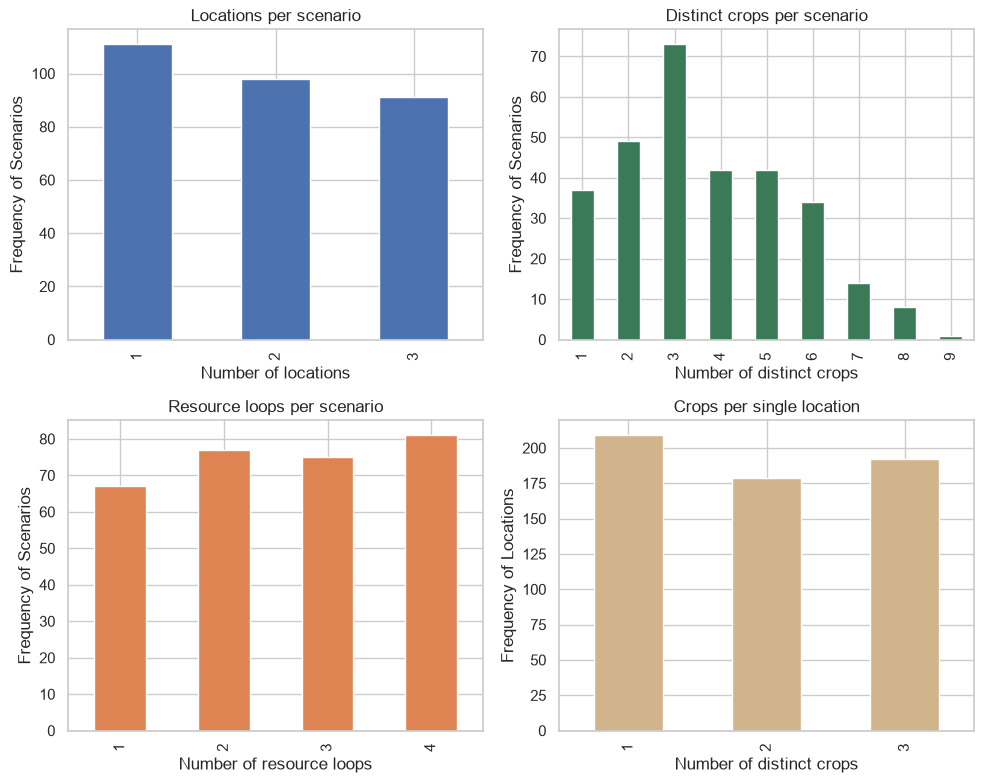

In [501]:
# Plot the scenario distributions and complexity
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

locations_per_scenario.value_counts().sort_index().plot(
    kind="bar", ax=axes[0][0], color=colors["locations"]
)
axes[0][0].set_xlabel("Number of locations")
axes[0][0].set_ylabel("Frequency of Scenarios")
axes[0][0].set_title("Locations per scenario")

crops_per_scenario.value_counts().sort_index().plot(
    kind="bar", ax=axes[0][1], color=colors["crops"]
)
axes[0][1].set_xlabel("Number of distinct crops")
axes[0][1].set_ylabel("Frequency of Scenarios")
axes[0][1].set_title("Distinct crops per scenario")

resources_per_scenario.value_counts().sort_index().plot(
    kind="bar", ax=axes[1][0], color=colors["resources"]
)
axes[1][0].set_xlabel("Number of resource loops")
axes[1][0].set_ylabel("Frequency of Scenarios")
axes[1][0].set_title("Resource loops per scenario")

crops_per_location.value_counts().sort_index().plot(
    kind="bar", ax=axes[1][1], color=colors["scenarios"]
)
axes[1][1].set_xlabel("Number of distinct crops")
axes[1][1].set_ylabel("Frequency of Locations")
axes[1][1].set_title("Crops per single location")

plt.tight_layout()
plt.show()

**Observation:** Hence, scenarios range from 1-3 locations and 1-3 crops per location, so complexity is fairly uniform across scenarios. No scenario is more complex than another, which means KPI comparisons across scenarios will not be affected by huge scale differences in the scenarios or crop-location-resource combinations.

## Feature Engineering - Key Performance Indicators (KPIs)

### Generate a KPIs Dataframe

As all of our calculations going forward rely mostly on the KPIs from the original datasets, we'll create a separate dataframe containing all of the combined, generated KPIs that we need.

We'll build one row per scenario (300 rows) with the 12 engineered KPIs defined in the proposal's KPI Calculation Guidelines.

**Assumption Log: `usage_fraction`**

The KPI guideline specifies a random `usage_fraction` (0.4–1.0) per scenario-location representing how much of a zone's area is actually cultivated. However, as no such column exists in the scenario datasets, we will assume that **`usage_fraction = 1.0`**, i.e., the full location area is available for cultivation and that full area is evenly split across the crop-systems placed at that location.


### Step 1: Crop and Location Scenarios Merge and KPI Definitions

- For every crop growing in a specific building location / zone, we check whether that location's *summer* daylight and temperature actually suit that crop which gives a compatibility flag (true - 1 or false - 0) per location.
- Each location's growing space is split evenly among however many crops share it, so no crop is given more space than it actually has.
- Compatible crops yield at their full potential (100%) but incompatible crops still produce a reduced amount (30%), which shows a crop surviving in not-ideal conditions instead of allocating 0% potential and have it completely produce nothing for comparison purposes.

From the above, we can calculate each combinations actual yield, its CO2 absorbtion, and its market value.

Then:
- All locations belonging to the same scenario are combined for total yield, total CO2 uptake, total market value, and overall compatibility (the average compatibility across all its crops).
- Total growing space is calculated such that a location shared by multiple crops is only counted once, not once per crop.
- Resource values (water, energy, greenhouse gas per kg produced) are averaged in a way that higher-yielding crops are given more weightage, since they contribute more to the scenario's overall footprint.

In [502]:
# Merge scenarios with their crop and location data
location_crop_merge = scenario_cl.merge(crops, on="crop_system_id", how="left")
location_crop_merge = location_crop_merge.merge(locations, left_on="location_id", right_on="id", how="left", suffixes=("", "_loc"))

location_crop_merge.head()

,scenario_id,location_id,crop_system_id,crop_name,cultivar,orientation,bia_system,temp_min,temp_max,dli_min,dli_max,hum_min,hum_max,yield_kg_m2,water_l_kg,energy_kwh_kg,ghg_kg_kg,co2_uptake_kg_kg,market_value_cad_kg,id,direction,orientation_loc,area,dli_spr,dli_sum,dli_aut,dli_win,rad_spr,rad_sum,rad_aut,rad_win,temp_spr_min,temp_spr_max,temp_sum_min,temp_sum_max,temp_aut_min,temp_aut_max,temp_win_min,temp_win_max,hum_spr_min,hum_spr_max,hum_sum_min,hum_sum_max,hum_aut_min,hum_aut_max,hum_win_min,hum_win_max
0,1,28,18,Strawberries,Albion,Horizontal,Raised-Beds,18,24,12.0,20,60,80,1.5,150.0,0.5,0.5,0.165150,10.0,28,North,Vertical,14,0.41,0.65,0.16,0.10,5.14,8.10,2.01,1.19,1,20,8,28,-2,24,-9,13,39,100,36,100,26,100,38,100
1,1,28,21,Culinary Herbs,Basil,Horizontal,Raised-Beds,20,30,12.0,26,50,70,3.0,70.0,0.5,0.4,0.165150,30.0,28,North,Vertical,14,0.41,0.65,0.16,0.10,5.14,8.10,2.01,1.19,1,20,8,28,-2,24,-9,13,39,100,36,100,26,100,38,100
2,2,37,24,Culinary Herbs,Cilantro,Horizontal,Raised-Beds,18,24,20.0,28,50,70,2.0,60.0,0.5,0.4,0.132120,20.0,37,Up,Horizontal,74,18.60,26.96,9.43,4.01,231.59,335.72,116.18,48.82,1,20,8,28,-2,24,-9,13,39,100,36,100,26,100,38,100
3,3,11,12,Tomato,Beefsteak,Vertical,Vertical Farm,20,26,22.0,30,60,75,60.0,40.0,22.0,1.6,0.082575,4.5,11,South,Vertical,123,14.67,13.33,15.52,11.50,182.71,166.07,191.19,140.14,1,20,8,28,-2,24,-9,13,39,100,36,100,26,100,38,100
4,3,11,24,Culinary Herbs,Cilantro,Horizontal,Raised-Beds,18,24,20.0,28,50,70,2.0,60.0,0.5,0.4,0.132120,20.0,11,South,Vertical,123,14.67,13.33,15.52,11.50,182.71,166.07,191.19,140.14,1,20,8,28,-2,24,-9,13,39,100,36,100,26,100,38,100


Alright, now that we have all the relevant data that we need per scenario for crops and location, let's calculate the KPIs related to them, and then take the sum / average so that we have one row per scenario.

In [503]:
# Assumption: usage_fraction = 1.0 (full usage)
location_crop_merge["usage_fraction"] = 1.0

# Calculate footprint per LOCATION first, then split it evenly across crops at that location
n_crops_at_location = location_crop_merge.groupby(["scenario_id", "location_id"])["crop_system_id"].transform("count")
location_crop_merge["footprint_share_m2"] = (location_crop_merge["area"] * location_crop_merge["usage_fraction"]) / n_crops_at_location

location_crop_merge[["scenario_id", "footprint_share_m2"]].head()

,scenario_id,footprint_share_m2
0,1,7.0
1,1,7.0
2,2,74.0
3,3,41.0
4,3,41.0


In [504]:
# Compatibility check (per combination): dli_ok AND temp_ok, using location's SUMMER values
# Using 1.5x tolerance for DLI, and a 3 degree buffer for temperature compatibility check
dli_ok = (location_crop_merge["dli_min"] <= location_crop_merge["dli_sum"]) & (location_crop_merge["dli_sum"] <= location_crop_merge["dli_max"] * 1.5)
temp_ok = (location_crop_merge["temp_min"] - 3 <= location_crop_merge["temp_sum_max"]) & (location_crop_merge["temp_sum_min"] <= location_crop_merge["temp_max"] + 3)
location_crop_merge["compatible"] = (dli_ok & temp_ok).astype(int)

location_crop_merge[["scenario_id", "compatible"]].head()

,scenario_id,compatible
0,1,0
1,1,0
2,2,1
3,3,0
4,3,0


In [505]:
# If compatible, yield multiplier = 1.0, else 0.3 (30% of potential yield)
location_crop_merge["yield_multiplier"] = np.where(location_crop_merge["compatible"] == 1, 1.0, 0.3)

# Per-combination yield, CO2 uptake, market value
location_crop_merge["combination_yield_kg"] = location_crop_merge["yield_kg_m2"] * location_crop_merge["footprint_share_m2"] * location_crop_merge["yield_multiplier"]
location_crop_merge["co2_uptake_contribution"] = location_crop_merge["co2_uptake_kg_kg"] * location_crop_merge["combination_yield_kg"]
location_crop_merge["market_value_contribution"] = location_crop_merge["market_value_cad_kg"] * location_crop_merge["combination_yield_kg"]

# Check the first few rows for calculated values
location_crop_merge[["scenario_id", "location_id", "crop_system_id", "footprint_share_m2",
            "compatible", "yield_multiplier", "combination_yield_kg", "co2_uptake_contribution",
            "market_value_contribution"]].head()

,scenario_id,location_id,crop_system_id,footprint_share_m2,compatible,yield_multiplier,combination_yield_kg,co2_uptake_contribution,market_value_contribution
0,1,28,18,7.0,0,0.3,3.15,0.520222,31.5
1,1,28,21,7.0,0,0.3,6.30,1.040445,189.0
2,2,37,24,74.0,1,1.0,148.00,19.553760,2960.0
3,3,11,12,41.0,0,0.3,738.00,60.940350,3321.0
4,3,11,24,41.0,0,0.3,24.60,3.250152,492.0


In [506]:
# total_footprint_m2: sum of UNIQUE (scenario, location) footprint, NOT per-combination,
# to avoid double-counting a location shared by multiple crops
location_footprint = location_crop_merge.drop_duplicates(["scenario_id", "location_id"])[
    ["scenario_id", "location_id", "area", "usage_fraction"]
].copy()
location_footprint["location_footprint_m2"] = location_footprint["area"] * location_footprint["usage_fraction"]
total_footprint = location_footprint.groupby("scenario_id")["location_footprint_m2"].sum().rename("total_footprint_m2")

total_footprint.head()

scenario_id
1     14.0
2     74.0
3    314.0
4    124.0
5    518.0
Name: total_footprint_m2, dtype: float64

In [507]:
# Group by scenario_id to calculate KPIs
grouped = location_crop_merge.groupby("scenario_id")
combination_kpis = pd.DataFrame({
    "compatibility_pct": grouped["compatible"].mean() * 100, # percentage of compatible combinations
    "total_yield_kg": grouped["combination_yield_kg"].sum(),
    "co2_uptake_kg": grouped["co2_uptake_contribution"].sum(),
    "market_value_cad": grouped["market_value_contribution"].sum(),
})

combination_kpis.head()

,compatibility_pct,total_yield_kg,co2_uptake_kg,market_value_cad
scenario_id,,,,
1,0.000000,9.45,1.560667,220.5
2,100.000000,148.00,19.553760,2960.0
3,50.000000,3198.10,442.031682,56838.0
4,57.142857,2814.60,249.118866,37611.7
5,25.000000,4111.10,674.549670,42262.5


In [508]:
# Helper function to calculate weighted average of a column based on combination_yield_kg
def yield_weighted_avg(g, col):
    w = g["combination_yield_kg"]
    return (g[col] * w).sum() / w.sum() if w.sum() > 0 else np.nan

# Calculate weighted averages for water, energy, and GHG per kg of yield
weighted_avgs = location_crop_merge.groupby("scenario_id").apply(
    lambda g: pd.Series({
        "avg_water_l_per_kg": yield_weighted_avg(g, "water_l_kg"),
        "avg_energy_kwh_per_kg": yield_weighted_avg(g, "energy_kwh_kg"),
        "avg_ghg_kg_per_kg": yield_weighted_avg(g, "ghg_kg_kg"),
    }),
    include_groups=False,
)

weighted_avgs.head()

,avg_water_l_per_kg,avg_energy_kwh_per_kg,avg_ghg_kg_per_kg
scenario_id,,,
1,96.666667,0.500000,0.433333
2,60.000000,0.500000,0.400000
3,35.323630,9.073294,0.975576
4,24.565018,8.573971,0.917828
5,48.262266,16.939639,1.529462


In [509]:
# Combine all KPIs into a single DataFrame for crops and locations
scenario_yield_kpis = total_footprint.to_frame().join(combination_kpis).join(weighted_avgs)
scenario_yield_kpis["yield_per_m2"] = scenario_yield_kpis["total_yield_kg"] / scenario_yield_kpis["total_footprint_m2"]

print(scenario_yield_kpis.shape)
scenario_yield_kpis.head()

(300, 9)


,total_footprint_m2,compatibility_pct,total_yield_kg,co2_uptake_kg,market_value_cad,avg_water_l_per_kg,avg_energy_kwh_per_kg,avg_ghg_kg_per_kg,yield_per_m2
scenario_id,,,,,,,,,
1,14.0,0.000000,9.45,1.560667,220.5,96.666667,0.500000,0.433333,0.675000
2,74.0,100.000000,148.00,19.553760,2960.0,60.000000,0.500000,0.400000,2.000000
3,314.0,50.000000,3198.10,442.031682,56838.0,35.323630,9.073294,0.975576,10.185032
4,124.0,57.142857,2814.60,249.118866,37611.7,24.565018,8.573971,0.917828,22.698387
5,518.0,25.000000,4111.10,674.549670,42262.5,48.262266,16.939639,1.529462,7.936486


### Step 2: Resource Scenarios Merge and KPI Definitions

We'll do the same thing to the resources dataframe that we did in step 1 for scenarios with crops and locations.

- Which circular technologies (like rainwater harvesting or composting) each scenario uses.
- Calculate how much water is recovered and how much energy is offset, based on the technologies present. Scenarios with no matching technology score 0% for that category.
- Reward scenarios that use a variety of technology types (water, energy, and soil-amendment) rather than just one, and combine all of this into a single circularity score.

In [510]:
resources_merge = scenario_r.merge(resources, on="resource_loop_id", how="left")

resources_merge.head()

,scenario_id,resource_loop_id,source,tech,output_type,recovery_yield_frac,space_m2,energy_kwh,energy_unit,category,annual_cost_cad,carbon_factor,carbon_unit,embodied_carbon
0,1,3,Organic waste,Anaerobic digester,Biogas,3.6,30,0.40,kWh/kg/year,Energy,6000.0,0.20,kgCO2e/kWh,400.0
1,1,1,Organic waste,Vermicomposting,Compost,0.4,10,0.02,kWh/kg/year,Amendment,1000.0,0.25,kgCO2e/kg,50.0
2,2,5,Organic waste,Black soldier fly,Protein,0.1,1,0.08,kWh/kg/year,Amendment,2000.0,3.00,kgCO2e/kg,208.3
3,2,7,Greywater,Filtration(BioGill),Treated water,0.8,15,0.50,kWh/m3/year,Water,2600.0,0.40,kgCO2e/m3,233.3
4,2,16,Organic waste,Biochar pyrolysis,Biochar,0.3,3,10.00,kWh/kg/year,Amendment,NaN,NaN,NaN,NaN


In [511]:
# Helper function to calculate category recovery percentage, capped at a maximum value
def category_recovery_pct(g, category, cap):
    sub = g[g["category"] == category]
    if len(sub) == 0:
        return 0.0
    return min(sub["recovery_yield_frac"].mean() * 100, cap)

# Calculate resource KPIs per scenario
resource_kpis = resources_merge.groupby("scenario_id").apply(
    lambda g: pd.Series({
        "water_recovery_pct": category_recovery_pct(g, "Water", 99),
        "energy_offset_pct": category_recovery_pct(g, "Energy", 95),
        "n_resource_categories": g["category"].nunique(),
    }),
    include_groups=False,
)

resource_kpis.head()

,water_recovery_pct,energy_offset_pct,n_resource_categories
scenario_id,,,
1,0.0,95.0,2.0
2,80.0,0.0,2.0
3,80.0,95.0,2.0
4,0.0,95.0,1.0
5,80.0,95.0,3.0


In [512]:
# Calculate circularity score
resource_kpis["resource_diversity"] = resource_kpis["n_resource_categories"] / 3
resource_kpis["circularity_score"] = 100 * (
    0.4 * resource_kpis["water_recovery_pct"] / 100
    + 0.4 * resource_kpis["energy_offset_pct"] / 100
    + 0.2 * resource_kpis["resource_diversity"]
)

print(resource_kpis.shape)
resource_kpis.head()

(300, 5)


,water_recovery_pct,energy_offset_pct,n_resource_categories,resource_diversity,circularity_score
scenario_id,,,,,
1,0.0,95.0,2.0,0.666667,51.333333
2,80.0,0.0,2.0,0.666667,45.333333
3,80.0,95.0,2.0,0.666667,83.333333
4,0.0,95.0,1.0,0.333333,44.666667
5,80.0,95.0,3.0,1.000000,90.000000


### Step 3: Final KPIs Dataframe Merge and Creation

- The crop-performance KPIs and the circular-technology KPIs need to be joined together, scenario by scenario, into one final table which contains one row per scenario with 12 performance indicators.
- Need to validate that we have the right number of scenarios (300 exactly) and that no scenario is missing any of its generated KPI values.

This final calculated KPI table is what we will use for all comparisons, visualization and model learning going forward.

In [513]:
scenario_kpi_df = scenario_yield_kpis.join(
    resource_kpis[["water_recovery_pct", "energy_offset_pct", "circularity_score"]]
).reset_index()

kpi_cols = ["total_footprint_m2", "compatibility_pct", "total_yield_kg", "yield_per_m2",
            "avg_water_l_per_kg", "avg_energy_kwh_per_kg", "avg_ghg_kg_per_kg",
            "co2_uptake_kg", "market_value_cad", "water_recovery_pct",
            "energy_offset_pct", "circularity_score"]

print(f"scenario_kpi_df shape: {scenario_kpi_df.shape}")
scenario_kpi_df.head()

scenario_kpi_df shape: (300, 13)


,scenario_id,total_footprint_m2,compatibility_pct,total_yield_kg,co2_uptake_kg,market_value_cad,avg_water_l_per_kg,avg_energy_kwh_per_kg,avg_ghg_kg_per_kg,yield_per_m2,water_recovery_pct,energy_offset_pct,circularity_score
0,1,14.0,0.000000,9.45,1.560667,220.5,96.666667,0.500000,0.433333,0.675000,0.0,95.0,51.333333
1,2,74.0,100.000000,148.00,19.553760,2960.0,60.000000,0.500000,0.400000,2.000000,80.0,0.0,45.333333
2,3,314.0,50.000000,3198.10,442.031682,56838.0,35.323630,9.073294,0.975576,10.185032,80.0,95.0,83.333333
3,4,124.0,57.142857,2814.60,249.118866,37611.7,24.565018,8.573971,0.917828,22.698387,0.0,95.0,44.666667
4,5,518.0,25.000000,4111.10,674.549670,42262.5,48.262266,16.939639,1.529462,7.936486,80.0,95.0,90.000000


In [514]:
# Validate that we have 300 scenarios and no NaNs in KPI columns
assert scenario_kpi_df.shape[0] == 300, "Expected exactly 300 scenarios"
assert scenario_kpi_df[kpi_cols].isna().sum().sum() == 0, "Unexpected NaNs in KPI columns"

### KPI Distribution and Correlation

Now, let's look at the overall distribution, and skewness of the generated KPI values from our data.

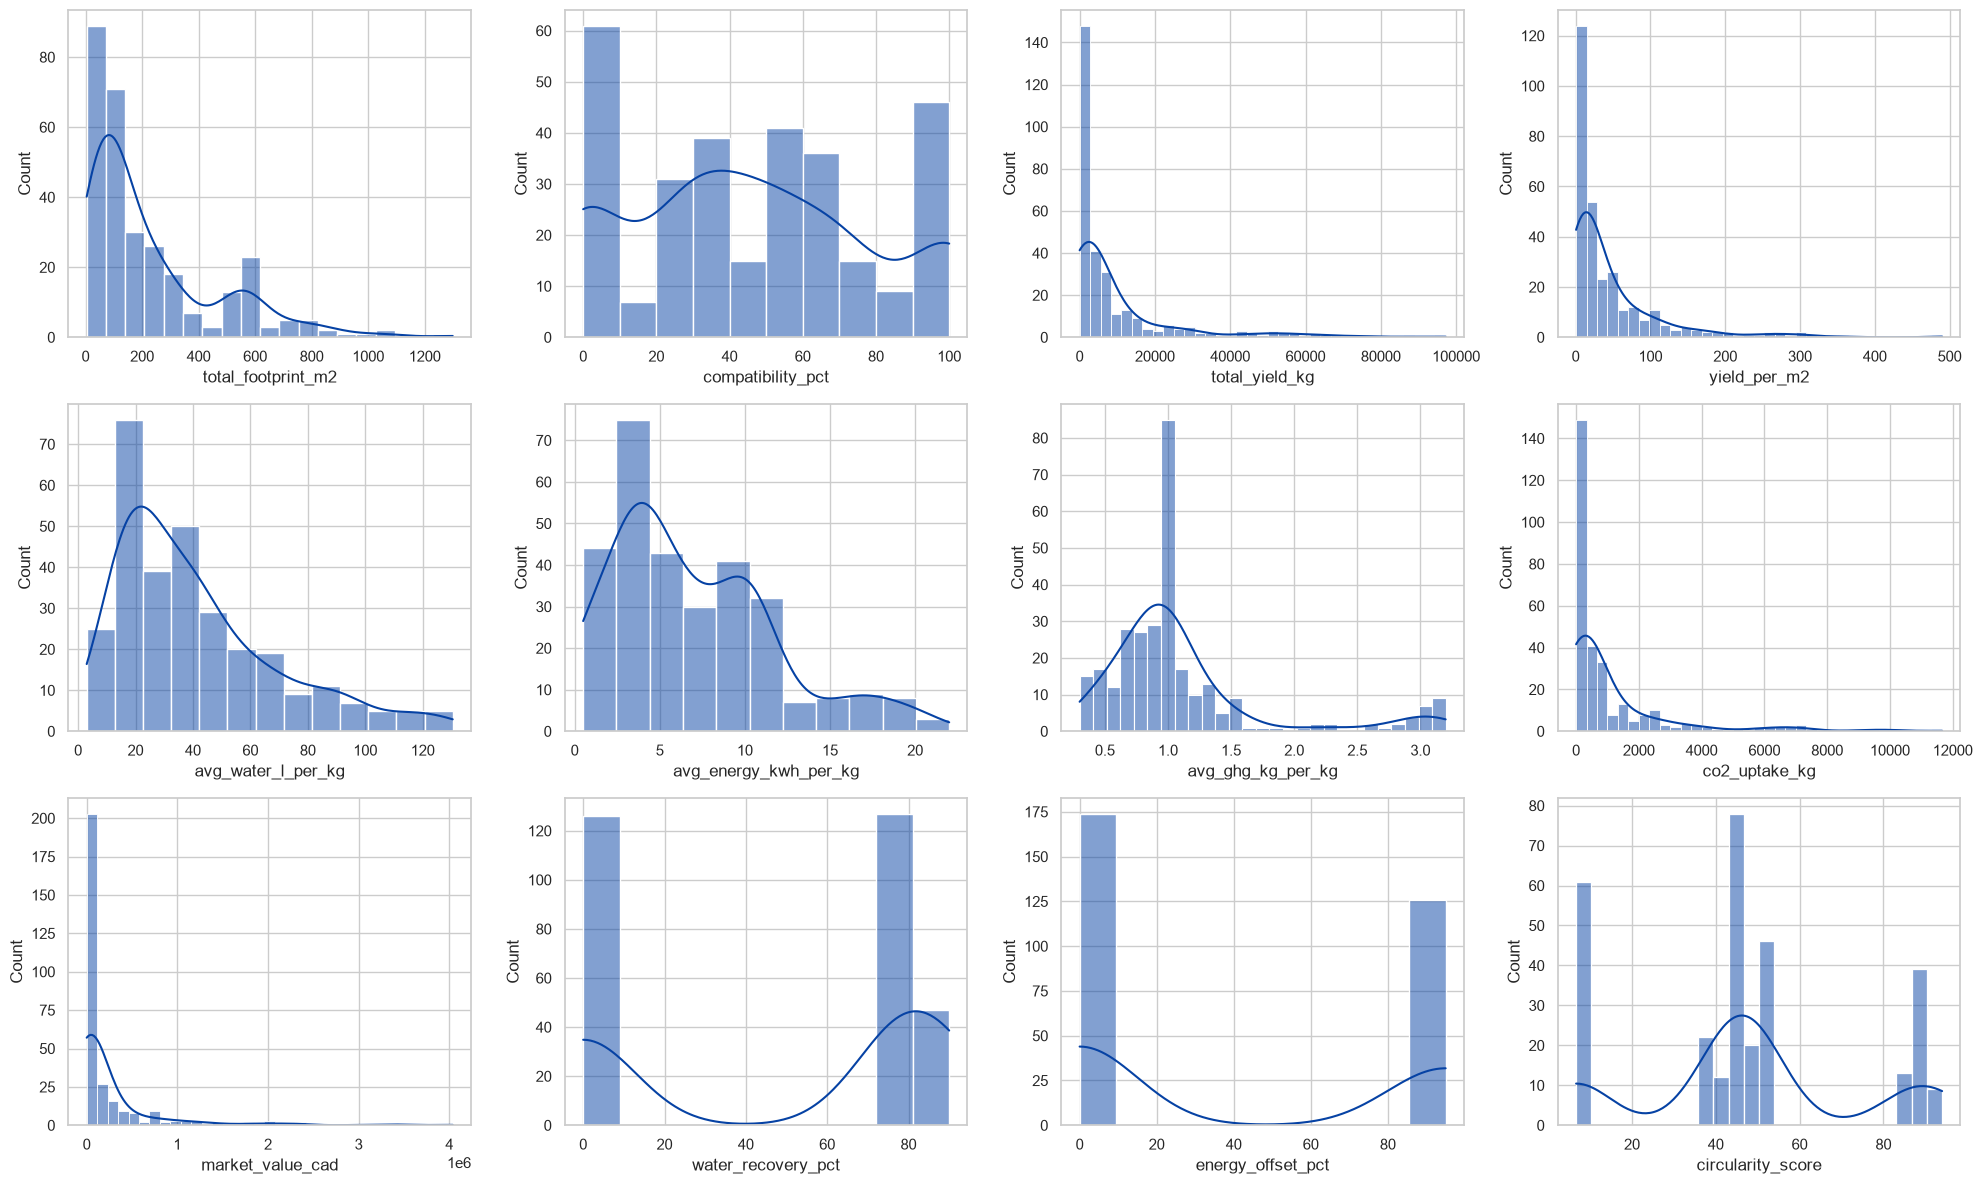

,total_footprint_m2,compatibility_pct,total_yield_kg,yield_per_m2,avg_water_l_per_kg,avg_energy_kwh_per_kg,avg_ghg_kg_per_kg,co2_uptake_kg,market_value_cad,water_recovery_pct,energy_offset_pct,circularity_score
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,3.000000e+02,300.000000,300.000000,300.000000
mean,229.020000,45.302116,9403.627417,46.049460,41.446094,6.938398,1.102706,1110.793054,2.530475e+05,47.555556,39.900000,46.826667
std,235.362525,33.102637,15931.161352,66.224391,28.202554,4.843722,0.656568,1899.528835,5.615426e+05,40.625528,46.966401,26.566890
min,4.000000,0.000000,9.450000,0.611438,3.000000,0.500000,0.300000,1.560667,2.205000e+02,0.000000,0.000000,6.666667
25%,59.750000,20.000000,828.058333,7.542175,20.000000,3.359950,0.746701,102.648982,8.542500e+03,0.000000,0.000000,38.666667
50%,127.000000,42.857143,2880.150000,18.246535,35.000000,6.009035,0.974966,339.468577,3.841725e+04,80.000000,0.000000,45.333333
75%,296.000000,66.666667,9234.000000,53.062896,53.599837,10.000000,1.110422,1058.305973,1.907221e+05,80.000000,95.000000,51.333333
max,1299.000000,100.000000,97217.400000,490.000000,130.442177,22.000000,3.200000,11661.549780,4.037415e+06,90.000000,95.000000,94.000000


In [515]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for ax, col in zip(axes.flat, kpi_cols):
    sns.histplot(scenario_kpi_df[col], kde=True, ax=ax, color=colors["kpis"])

plt.tight_layout()
plt.show()

scenario_kpi_df[kpi_cols].describe()

In [520]:
# Check skewness
skewness = scenario_kpi_df[kpi_cols].skew().sort_values(ascending=False)
print("Skewness:\n", skewness)

Skewness:
 market_value_cad         3.798103
co2_uptake_kg            2.907357
yield_per_m2             2.886484
total_yield_kg           2.778558
avg_ghg_kg_per_kg        1.979179
total_footprint_m2       1.553560
avg_water_l_per_kg       1.220280
avg_energy_kwh_per_kg    0.879918
energy_offset_pct        0.325808
compatibility_pct        0.215013
circularity_score        0.130764
water_recovery_pct      -0.311759
dtype: float64


As a lot of the above values have skewness > 0.5, we will need to log-transform these so that the data is more uniform for analysis, clustering and classification later.

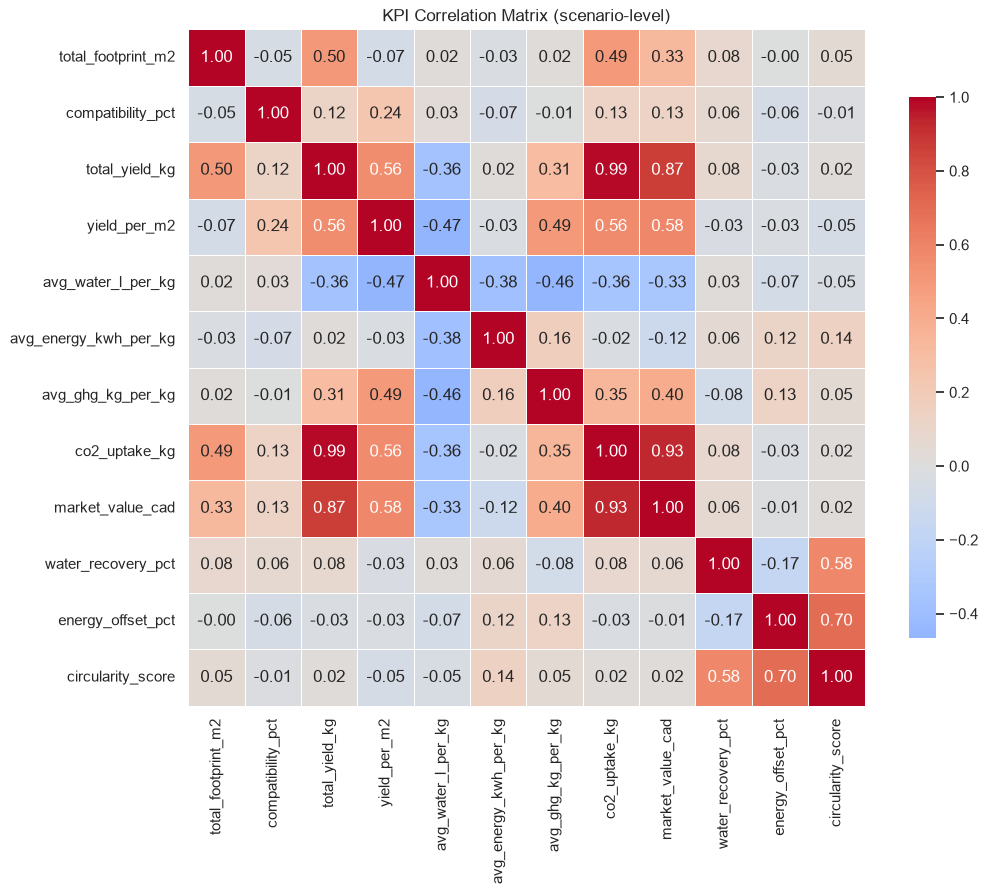

In [516]:
corr = scenario_kpi_df[kpi_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("KPI Correlation Matrix (scenario-level)")
plt.tight_layout()
plt.show()

In [517]:
# Correlation pairs with highest magnitude (excluding self-correlation)
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().sort_values(key=abs, ascending=False)
print("KPI correlations:")
print(pairs.head(10))

KPI correlations:
total_yield_kg      co2_uptake_kg        0.985062
co2_uptake_kg       market_value_cad     0.931326
total_yield_kg      market_value_cad     0.872551
energy_offset_pct   circularity_score    0.699367
yield_per_m2        market_value_cad     0.584459
water_recovery_pct  circularity_score    0.579193
yield_per_m2        co2_uptake_kg        0.560740
total_yield_kg      yield_per_m2         0.556368
total_footprint_m2  total_yield_kg       0.504815
yield_per_m2        avg_ghg_kg_per_kg    0.491364
dtype: float64


**Observation:** 
- the highest correlation scores exist between:
    - total_yield_kg, co2_uptake_kg, market_value_cad and yield_per_m2.
- `water_recovery_pct`, `energy_offset_pct`, have a correlation to `circularity_score` as the score is directly calculated from these 2 values, so these high values are expected.